<h1>Importing needed frameworks</h1>

In [259]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import seaborn as sns

<h1>Loading datasets</h1>

In [ ]:
obesity_adults = pd.read_csv('data/obesity_adults.csv')
obesity_kids = pd.read_csv('data/obesity_kids.csv')
gdp = pd.read_csv('data/gdp.csv')

<h1>Utils</h1>

In [255]:
url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_50m_admin_0_countries.geojson"
eu_country_codes = {
    'Austria': 'AUT',
    'Belgium': 'BEL',
    'Bulgaria': 'BGR',
    'Croatia': 'HRV',
    'Cyprus': 'CYP',
    'Czechia': 'CZE',
    'Denmark': 'DNK',
    'Estonia': 'EST',
    'Finland': 'FIN',
    'France': 'FRA',
    'Germany': 'DEU',
    'Greece': 'GRC',
    'Hungary': 'HUN',
    'Ireland': 'IRL',
    'Italy': 'ITA',
    'Latvia': 'LVA',
    'Lithuania': 'LTU',
    'Luxembourg': 'LUX',
    'Malta': 'MLT',
    'Netherlands (Kingdom of the)': 'NLD',
    'Poland': 'POL',
    'Portugal': 'PRT',
    'Romania': 'ROU',
    'Slovakia': 'SVK',
    'Slovenia': 'SVN',
    'Spain': 'ESP',
    'Sweden': 'SWE'
}
iso3_to_iso2 = {
    'AUT': 'AT',
    'BEL': 'BE',
    'BGR': 'BG',
    'HRV': 'HR',
    'CYP': 'CY',
    'CZE': 'CZ',
    'DNK': 'DK',
    'EST': 'EE',
    'FIN': 'FI',
    'FRA': 'FR',
    'DEU': 'DE',
    'GRC': 'GR',
    'HUN': 'HU',
    'IRL': 'IE',
    'ITA': 'IT',
    'LVA': 'LV',
    'LTU': 'LT',
    'LUX': 'LU',
    'MLT': 'MT',
    'NLD': 'NL',
    'POL': 'PL',
    'PRT': 'PT',
    'ROU': 'RO',
    'SVK': 'SK',
    'SVN': 'SI',
    'ESP': 'ES',
    'SWE': 'SE'
}

<h1>Preprocessing and Cleaning Data</h1>

In [256]:

#Cleaning obesity for adults dataset
obesity = pd.concat([obesity_kids,obesity_adults])
obesity = obesity[['GEO_NAME_SHORT','DIM_TIME','DIM_SEX','DIM_AGE','RATE_PER_100_N']].copy()
obesity.columns = ['country','year','sex','age','obesity_rate']
obesity['country'] = obesity['country'].map(eu_country_codes)
obesity = obesity[obesity['country'].notna()]


<h1>Obesity Map<h1>

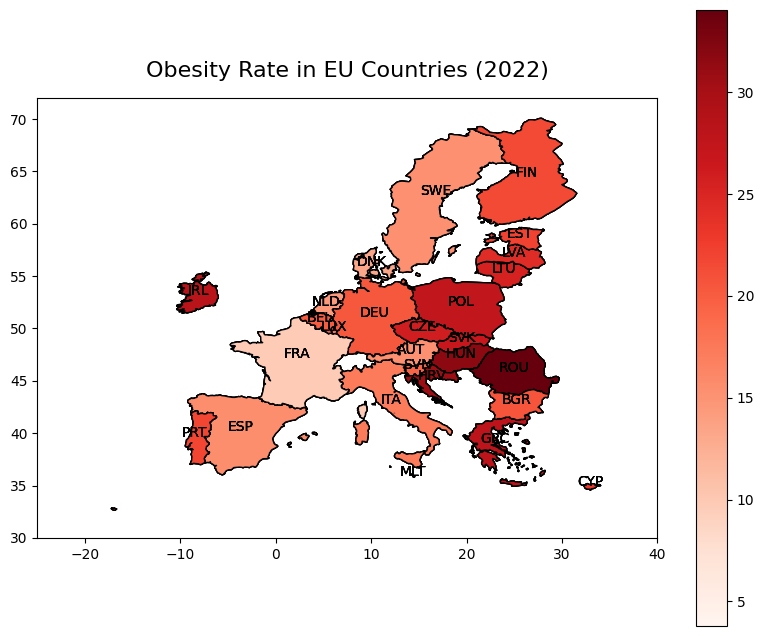

In [260]:

#Preparing the used data and map
data = obesity[(obesity['sex'] == 'TOTAL') & (obesity['year'] == 2022)]
world = gpd.read_file(url)
world.loc[(world['SOV_A3'] == 'FR1') & (world['NAME'] == 'France'),'SOV_A3'] = 'FRA'
world.loc[(world['SOV_A3'] == 'FI1') & (world['NAME'] == 'Finland'),'SOV_A3'] = 'FIN'
world.loc[(world['SOV_A3'] == 'NL1') & (world['NAME'] == 'Netherlands'),'SOV_A3'] = 'NLD'
world.loc[(world['SOV_A3'] == 'DN1') & (world['NAME'] == 'Denmark'),'SOV_A3'] = 'DNK'
eu_map = world[world['SOV_A3'].isin(data['country'])]
#Filtering non-EU countries out

merged = eu_map.merge(data,left_on='SOV_A3',right_on='country',how='left')
figure, axis = plt.subplots(figsize=(10, 8))
merged.plot(column='obesity_rate',cmap='Reds',legend=True,edgecolor='black',linewidth=1,ax=axis)

axis.set_xlim(-25, 40)
axis.set_ylim(30, 72)

# Labels
axis.set_title('Obesity Rate in EU Countries (2022)', fontsize=16, pad=15)
for idx, row in merged.iterrows():
    axis.text(
        row.geometry.centroid.x + 5 if row['SOV_A3'] == 'FRA' else row.geometry.centroid.x,
        row.geometry.centroid.y + 5 if row['SOV_A3'] == 'FRA' else row.geometry.centroid.y,
        row['SOV_A3'],fontsize=10,ha='center'
    )

<h1>Analysis Obesity and sex accross EU countries</h1>

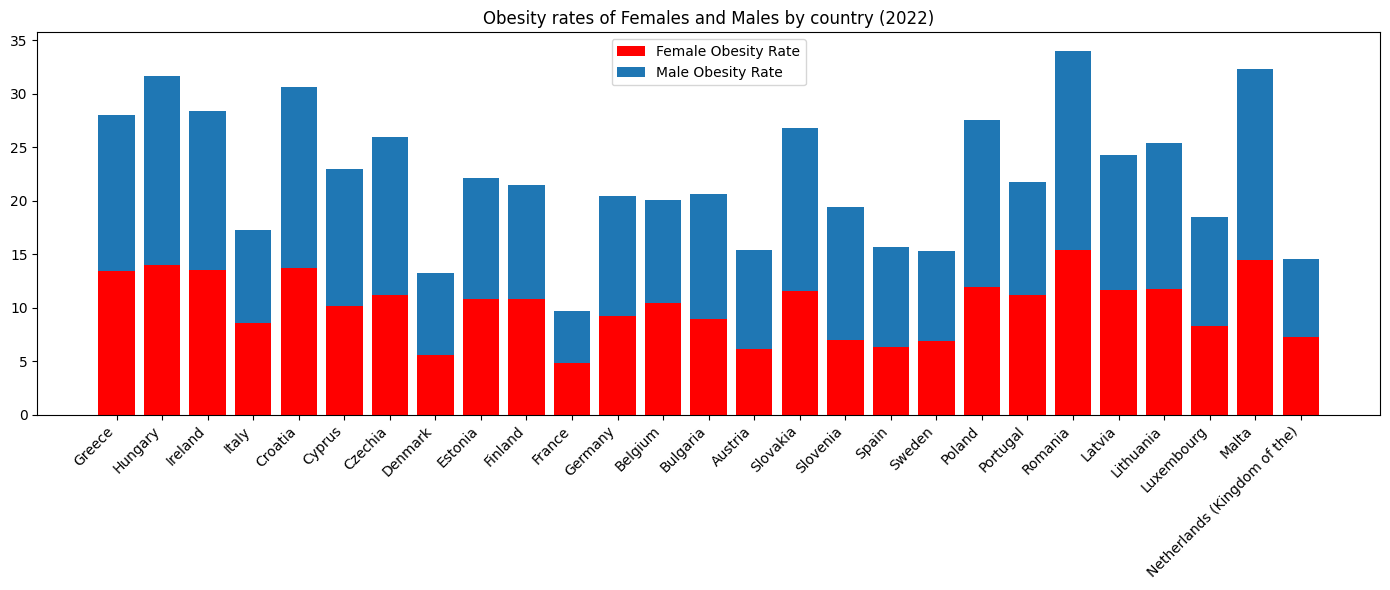

In [ ]:
female_obesity = obesity[(obesity['sex'] == 'FEMALE') & (obesity['year'] == 2022) & (obesity['age'] == 'Y_GE18')]
male_obesity = obesity[(obesity['sex'] == 'MALE') & (obesity['year'] == 2022) & (obesity['age'] == 'Y_GE18')]
total = obesity[(obesity['sex'] == 'TOTAL') & (obesity['year'] == 2022) & (obesity['age'] == 'Y_GE18')]

df = pd.merge(female_obesity[['country','obesity_rate']],male_obesity[['country','obesity_rate']],on='country',suffixes=('_females','_males'))
df = df.merge(total[['country','obesity_rate']],on='country')
df = df.rename(columns={'obesity_rate':'obesity_rate_total'})
scaler = df['obesity_rate_total'] / (df['obesity_rate_females'] + df['obesity_rate_males'])
df['obesity_female_scaled'] = df['obesity_rate_females'] * scaler
df['obesity_male_scaled'] = df['obesity_rate_males'] * scaler
df['country'] = df['country'].map({v:k for k,v in eu_country_codes.items()})

plt.figure(figsize=(14,6))
plt.bar(df['country'],df['obesity_female_scaled'],label='Female Obesity Rate',color='red')
plt.bar(df['country'],df['obesity_male_scaled'],bottom=df['obesity_female_scaled'],label='Male Obesity Rate')
plt.title('Obesity rates of Females and Males by country (2022)')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.legend()
plt.show()


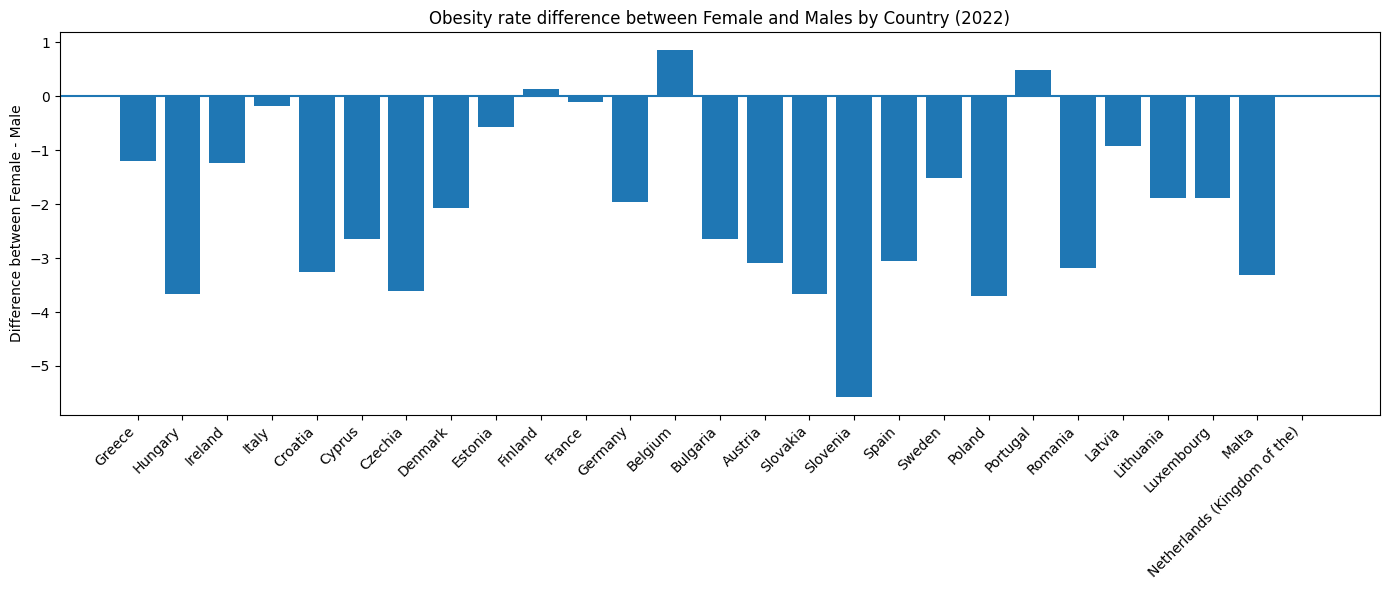

In [ ]:
df['obesity_diff'] = df['obesity_female_scaled'] - df['obesity_male_scaled']
df
plt.figure(figsize=(14,6))
plt.bar(df['country'],df['obesity_diff'])
plt.axhline(0)
plt.xticks(rotation=45,ha='right')
plt.ylabel('Difference between Female - Male')
plt.title('Obesity rate difference between Female and Males by Country (2022)')
plt.tight_layout()
plt.show()

<h1>Obesity and GPD Analysis</h1>

In [ ]:
import pandas as pd
df = pd.merge(obesity,gdp[gdp['Country Code'].isin(eu_country_codes.values())][['Country Code','2022']],left_on='country',right_on='Country Code')
df = df[(df['year'] == 2022) & (df['sex'] == 'TOTAL') & (df['age'] == 'Y_GE18')]

plt.figure(figsize=(10,6))
plt.scatter(df['2022'], df['obesity_rate'])
plt.xlabel("GDP per capita (PPP, 2022)")
plt.ylabel("Obesity rate (%)")
plt.title("Obesity vs GDP per capita (2022)")

# Labels
for i, text in enumerate(df["Country Code"]):
    plt.annotate(
        text,(df["2022"].iloc[i], df["obesity_rate"].iloc[i]),textcoords="offset points",
        xytext=(3,3),rotation=45,fontsize=8
    )
    
plt.tight_layout()
plt.show()

TypeError: 'module' object is not subscriptable